# 🌿 AI-Powered Plant Disease Detection System

## Deep Learning | Computer Vision | Transfer Learning

---

### Project Objective

The objective of this project is to develop an AI-based system capable of identifying plant diseases from leaf images using Deep Learning techniques.

The model will classify plant leaves into multiple disease categories and provide accurate predictions that can later be integrated into a Streamlit web application for real-world usage.

---

### Business Problem

Plant diseases significantly reduce agricultural productivity.

Manual diagnosis:
- Requires expert knowledge
- Time-consuming
- Expensive
- Not always available in rural areas

An AI-powered solution can provide:
- Fast diagnosis
- High accuracy
- Low cost
- Easy accessibility

---

### Project Workflow

Dataset
↓

Data Inspection
↓

Image Preprocessing

↓

Transfer Learning (CNN)

↓

Model Training

↓

Evaluation

↓

Prediction

↓

Streamlit Deployment

↓

GitHub

---

### Expected Outcome

A production-ready Deep Learning model capable of identifying plant diseases with high accuracy and deployable as a web application.

# 📦 Import Required Libraries

In this section, we import all the necessary libraries required throughout the project.

These libraries help us in:

- Data manipulation
- Image processing
- Deep Learning
- Visualization
- File handling
- Model evaluation

In [60]:
# ==============================
# Standard Libraries
# ==============================

import os
import random
import warnings

warnings.filterwarnings("ignore")

# ==============================
# Data Handling
# ==============================

import numpy as np
import pandas as pd

# ==============================
# Visualization
# ==============================

import matplotlib.pyplot as plt

# ==============================
# TensorFlow
# ==============================

import tensorflow as tf

from tensorflow.keras.preprocessing.image import load_img, img_to_array

### Observation

All required libraries were imported successfully.

These libraries will be used throughout the project for data handling, visualization, image preprocessing, and Deep Learning model development.

# ⚙️ Environment Information

Before building any Deep Learning model, it is important to verify the software environment.

This helps ensure reproducibility and avoids compatibility issues during model development and deployment.

In [61]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print("TensorFlow :", tf.__version__)
print("NumPy      :", np.__version__)
print("Pandas     :", pd.__version__)

TensorFlow : 2.20.0
NumPy      : 2.0.2
Pandas     : 2.2.2


# 📂 Define Project Paths

To maintain a professional project structure, all important folders are defined using variables.

This approach avoids hardcoded paths and improves code readability, portability, and maintainability.

In [ ]:
# Root Project Directory
PROJECT_PATH = "/content/drive/MyDrive/Final_Project"

# Dataset Paths
TRAIN_DIR = os.path.join(
    PROJECT_PATH,
    "dataset",
    "raw",
    "New Plant Diseases Dataset(Augmented)",
    "train"
)

VALID_DIR = os.path.join(
    PROJECT_PATH,
    "dataset",
    "raw",
    "New Plant Diseases Dataset(Augmented)",
    "valid"
)

TEST_DIR = os.path.join(
    PROJECT_PATH,
    "dataset",
    "raw",
    "test"
)

# Output
MODEL_DIR = os.path.join(PROJECT_PATH, "models")
OUTPUT_DIR = os.path.join(PROJECT_PATH, "outputs")

# 📁 Verify Dataset Structure

Before training a model, it is essential to verify that all dataset directories exist and are accessible.

This step helps detect missing folders or incorrect paths at an early stage.

In [ ]:
import os

print("Train Exists :", os.path.exists(TRAIN_DIR))
print("Validation Exists :", os.path.exists(VALID_DIR))
print("Test Exists :", os.path.exists(TEST_DIR))

Train Exists : True
Validation Exists : True
Test Exists : True


### Observation

All dataset directories are available and correctly linked.

The project can now proceed to dataset exploration and preprocessing.

# 📊 Dataset Exploration (EDA)

## Why Perform EDA?

Before training any Deep Learning model, it is essential to understand the dataset.

Exploratory Data Analysis (EDA) helps us answer questions such as:

- How many disease classes are available?
- Is the dataset balanced?
- What is the image resolution?
- Are all images RGB?
- Are there any missing or corrupted images?

A well-performed EDA reduces future errors and improves model performance.

In [ ]:
# Count total classes

classes = sorted(os.listdir(TRAIN_DIR))

print("Total Classes :", len(classes))

Total Classes : 38


### 📌 Observation

- The training dataset contains **38 unique plant disease categories**.
- Each category is stored in a separate folder inside the training directory.
- These folder names will serve as the target labels during model training.
- The output layer of the Deep Learning model will therefore contain **38 neurons**, one for each class.

> **Conclusion:** The dataset structure is valid and ready for further exploration.

# 🏷️ Display Disease Categories

After identifying the total number of classes, the next step is to inspect their names.

Each folder in the training dataset represents a unique plant disease category.

Displaying the class names helps verify that:

- All disease categories are present.
- Folder names are correctly formatted.
- Labels are ready for model training.

In [ ]:
# Display all disease categories

for index, class_name in enumerate(classes, start=1):
    print(f"{index}. {class_name}")

1. Apple___Apple_scab
2. Apple___Black_rot
3. Apple___Cedar_apple_rust
4. Apple___healthy
5. Blueberry___healthy
6. Cherry_(including_sour)___Powdery_mildew
7. Cherry_(including_sour)___healthy
8. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
9. Corn_(maize)___Common_rust_
10. Corn_(maize)___Northern_Leaf_Blight
11. Corn_(maize)___healthy
12. Grape___Black_rot
13. Grape___Esca_(Black_Measles)
14. Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
15. Grape___healthy
16. Orange___Haunglongbing_(Citrus_greening)
17. Peach___Bacterial_spot
18. Peach___healthy
19. Pepper,_bell___Bacterial_spot
20. Pepper,_bell___healthy
21. Potato___Early_blight
22. Potato___Late_blight
23. Potato___healthy
24. Raspberry___healthy
25. Soybean___healthy
26. Squash___Powdery_mildew
27. Strawberry___Leaf_scorch
28. Strawberry___healthy
29. Tomato___Bacterial_spot
30. Tomato___Early_blight
31. Tomato___Late_blight
32. Tomato___Leaf_Mold
33. Tomato___Septoria_leaf_spot
34. Tomato___Spider_mites Two-spotted_spider_

### 📌 Observation

- The dataset contains **38 unique plant disease categories**.
- Each category is represented by a separate folder inside the training directory.
- The folder names clearly indicate both the **plant type** and the **associated disease** (or healthy condition).
- These folder names will automatically act as the class labels during model training.

> **Conclusion:** The dataset has been successfully loaded, and all disease categories are available for further analysis.

# 📋 Create Dataset Summary

To perform structured analysis, we convert the folder information into a Pandas DataFrame.

This allows us to use familiar Pandas functions such as:

- head()
- tail()
- info()
- describe()
- sort_values()

for further Exploratory Data Analysis (EDA).

In [ ]:
# Create DataFrame of all disease classes

class_df = pd.DataFrame({
    "Class_ID": range(1, len(classes) + 1),
    "Disease_Name": classes
})

class_df

,Class_ID,Disease_Name
0,1,Apple___Apple_scab
1,2,Apple___Black_rot
2,3,Apple___Cedar_apple_rust
3,4,Apple___healthy
4,5,Blueberry___healthy
5,6,Cherry_(including_sour)___Powdery_mildew
6,7,Cherry_(including_sour)___healthy
7,8,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...
8,9,Corn_(maize)___Common_rust_
9,10,Corn_(maize)___Northern_Leaf_Blight


In [ ]:
class_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Class_ID      38 non-null     int64 
 1   Disease_Name  38 non-null     object
dtypes: int64(1), object(1)
memory usage: 740.0+ bytes


### 📌 Observation

- The DataFrame contains **38 rows**, representing 38 unique plant disease classes.
- There are **2 columns**:
  - **Class_ID:** Integer identifier assigned to each disease class.
  - **Disease_Name:** Name of the plant disease category.
- No missing values are present in either column.
- The dataset occupies very little memory (approximately **740 bytes**), indicating that this DataFrame only stores metadata about the classes and not the actual images.

> **Conclusion:** The class metadata has been successfully organized into a clean and complete DataFrame, making it suitable for further analysis.

In [ ]:
class_df.describe(include="all")

,Class_ID,Disease_Name
count,38.000000,38
unique,NaN,38
top,NaN,Apple___Apple_scab
freq,NaN,1
mean,19.500000,NaN
std,11.113055,NaN
min,1.000000,NaN
25%,10.250000,NaN
50%,19.500000,NaN
75%,28.750000,NaN


### 📌 Observation

- The dataset contains information for **38 unique disease categories**.
- Each disease name appears only **once**, confirming that there are no duplicate class labels.
- The **Class_ID** ranges from **1 to 38**, providing a unique identifier for every disease class.
- Since **Disease_Name** is a categorical feature, statistical measures such as mean and standard deviation are not applicable.

> **Conclusion:** Every disease category is unique, and the class labels are correctly organized without duplication.

In [ ]:
class_df.head()

,Class_ID,Disease_Name
0,1,Apple___Apple_scab
1,2,Apple___Black_rot
2,3,Apple___Cedar_apple_rust
3,4,Apple___healthy
4,5,Blueberry___healthy


### 📌 Observation

- The first five records of the DataFrame have been displayed successfully.
- Each row represents a unique disease category along with its assigned Class_ID.
- The DataFrame structure is clear and easy to understand.

> **Conclusion:** The DataFrame has been created correctly and is ready for further Exploratory Data Analysis (EDA).

In [ ]:
class_df.tail()

,Class_ID,Disease_Name
33,34,Tomato___Spider_mites Two-spotted_spider_mite
34,35,Tomato___Target_Spot
35,36,Tomato___Tomato_Yellow_Leaf_Curl_Virus
36,37,Tomato___Tomato_mosaic_virus
37,38,Tomato___healthy


### 📌 Observation

- The last five disease categories have been displayed successfully.
- The dataset includes different tomato disease categories as well as the healthy class.
- This confirms that all disease categories have been loaded completely from the training directory.

> **Conclusion:** The DataFrame correctly stores all disease classes from the first category to the last without any missing entries.

In [ ]:
image_count = {}

for class_name in classes:
    class_path = os.path.join(TRAIN_DIR, class_name)

    image_count[class_name] = len([
        file
        for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

image_count

{'Apple___Apple_scab': 2016,
 'Apple___Black_rot': 1987,
 'Apple___Cedar_apple_rust': 1760,
 'Apple___healthy': 2008,
 'Blueberry___healthy': 1816,
 'Cherry_(including_sour)___Powdery_mildew': 1683,
 'Cherry_(including_sour)___healthy': 1826,
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 1642,
 'Corn_(maize)___Common_rust_': 1907,
 'Corn_(maize)___Northern_Leaf_Blight': 1908,
 'Corn_(maize)___healthy': 1859,
 'Grape___Black_rot': 1888,
 'Grape___Esca_(Black_Measles)': 1920,
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 1722,
 'Grape___healthy': 1692,
 'Orange___Haunglongbing_(Citrus_greening)': 2010,
 'Peach___Bacterial_spot': 1838,
 'Peach___healthy': 1728,
 'Pepper,_bell___Bacterial_spot': 1913,
 'Pepper,_bell___healthy': 1988,
 'Potato___Early_blight': 1939,
 'Potato___Late_blight': 1939,
 'Potato___healthy': 1824,
 'Raspberry___healthy': 1781,
 'Soybean___healthy': 2022,
 'Squash___Powdery_mildew': 1736,
 'Strawberry___Leaf_scorch': 1774,
 'Strawberry___healthy': 1824,
 '

# 📊 Create Image Count DataFrame

The image counts collected from each disease category are converted into a Pandas DataFrame.

This structured format makes it easier to perform statistical analysis, visualization, sorting, and further Exploratory Data Analysis (EDA).

Using a DataFrame also provides a cleaner and more organized representation of the dataset compared to a Python dictionary.

In [ ]:
# Convert dictionary into DataFrame

image_count_df = pd.DataFrame(
    image_count.items(),
    columns=["Disease_Name", "Image_Count"]
)

image_count_df

,Disease_Name,Image_Count
0,Apple___Apple_scab,2016
1,Apple___Black_rot,1987
2,Apple___Cedar_apple_rust,1760
3,Apple___healthy,2008
4,Blueberry___healthy,1816
5,Cherry_(including_sour)___Powdery_mildew,1683
6,Cherry_(including_sour)___healthy,1826
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,1642
8,Corn_(maize)___Common_rust_,1907
9,Corn_(maize)___Northern_Leaf_Blight,1908


In [ ]:
image_count_df.head()

,Disease_Name,Image_Count
0,Apple___Apple_scab,2016
1,Apple___Black_rot,1987
2,Apple___Cedar_apple_rust,1760
3,Apple___healthy,2008
4,Blueberry___healthy,1816


In [ ]:
image_count_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Disease_Name  38 non-null     object
 1   Image_Count   38 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 740.0+ bytes


In [ ]:
image_count_df.describe()

,Image_Count
count,38.000000
mean,1849.868421
std,105.724315
min,1642.000000
25%,1763.500000
50%,1844.500000
75%,1924.500000
max,2022.000000


In [ ]:
image_count_df.sort_values(
    by="Image_Count",
    ascending=False
)

,Disease_Name,Image_Count
24,Soybean___healthy,2022
0,Apple___Apple_scab,2016
15,Orange___Haunglongbing_(Citrus_greening),2010
3,Apple___healthy,2008
19,"Pepper,_bell___healthy",1988
1,Apple___Black_rot,1987
35,Tomato___Tomato_Yellow_Leaf_Curl_Virus,1961
21,Potato___Late_blight,1939
20,Potato___Early_blight,1939
37,Tomato___healthy,1926


## 📌 Observations

- The dataset contains image count information for all 38 disease categories.
- The data has been successfully converted into a Pandas DataFrame.
- There are no missing values in the dataset.
- Each disease category is associated with its corresponding number of images.
- The DataFrame structure is suitable for further statistical analysis and visualization.

> **Conclusion:** The dataset is clean, structured, and ready for detailed Exploratory Data Analysis (EDA).

# 📊 Statistical Analysis of Image Distribution

In this section, we analyze the distribution of images across different disease categories.

The objective is to identify:

- Disease category with the highest number of images
- Disease category with the lowest number of images
- Average number of images per class
- Whether the dataset is balanced or imbalanced

This analysis helps us understand the overall quality of the dataset before training the Deep Learning model.

In [ ]:
# Highest Image Count:

highest_class = image_count_df.loc[
    image_count_df['Image_Count'].idxmax()
]

highest_class


,24
Disease_Name,Soybean___healthy
Image_Count,2022


In [ ]:
# Lowest Image Count:

lowest_class =image_count_df.loc[
    image_count_df['Image_Count'].idxmin()
]

lowest_class


,7
Disease_Name,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...
Image_Count,1642


In [ ]:
# Average Image Count:

average_image_count= image_count_df['Image_Count'].mean()

print(f"Average Images per Class : {average_image_count:.2f}")


Average Images per Class : 1849.87


In [ ]:
# Difference between Highest and lowest:

difference = (
    image_count_df["Image_Count"].max()
    -
    image_count_df["Image_Count"].min()
)

print("Difference :", difference)

Difference : 380


## 📌 Observations

- The dataset consists of **38 disease categories** with a total image distribution that is fairly consistent across classes.
- The class with the highest number of images is **Soybean___healthy** containing **2022 images**.
- The class with the lowest number of images is **Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot** containing **1642 images**.
- The average number of images available per class is approximately **1849.87**.
- The difference between the largest and smallest class is **380 images**, indicating that the dataset is relatively balanced.

> **Conclusion:** The dataset does not exhibit severe class imbalance, making it suitable for training a Deep Learning classification model without requiring major class balancing techniques.

## 💡 Key Insights

- Most disease categories contain a similar number of images.
- A balanced dataset helps the model learn each disease category more effectively.
- Since no class dominates the dataset, the risk of prediction bias is reduced.
- The dataset is well-prepared for CNN-based image classification.

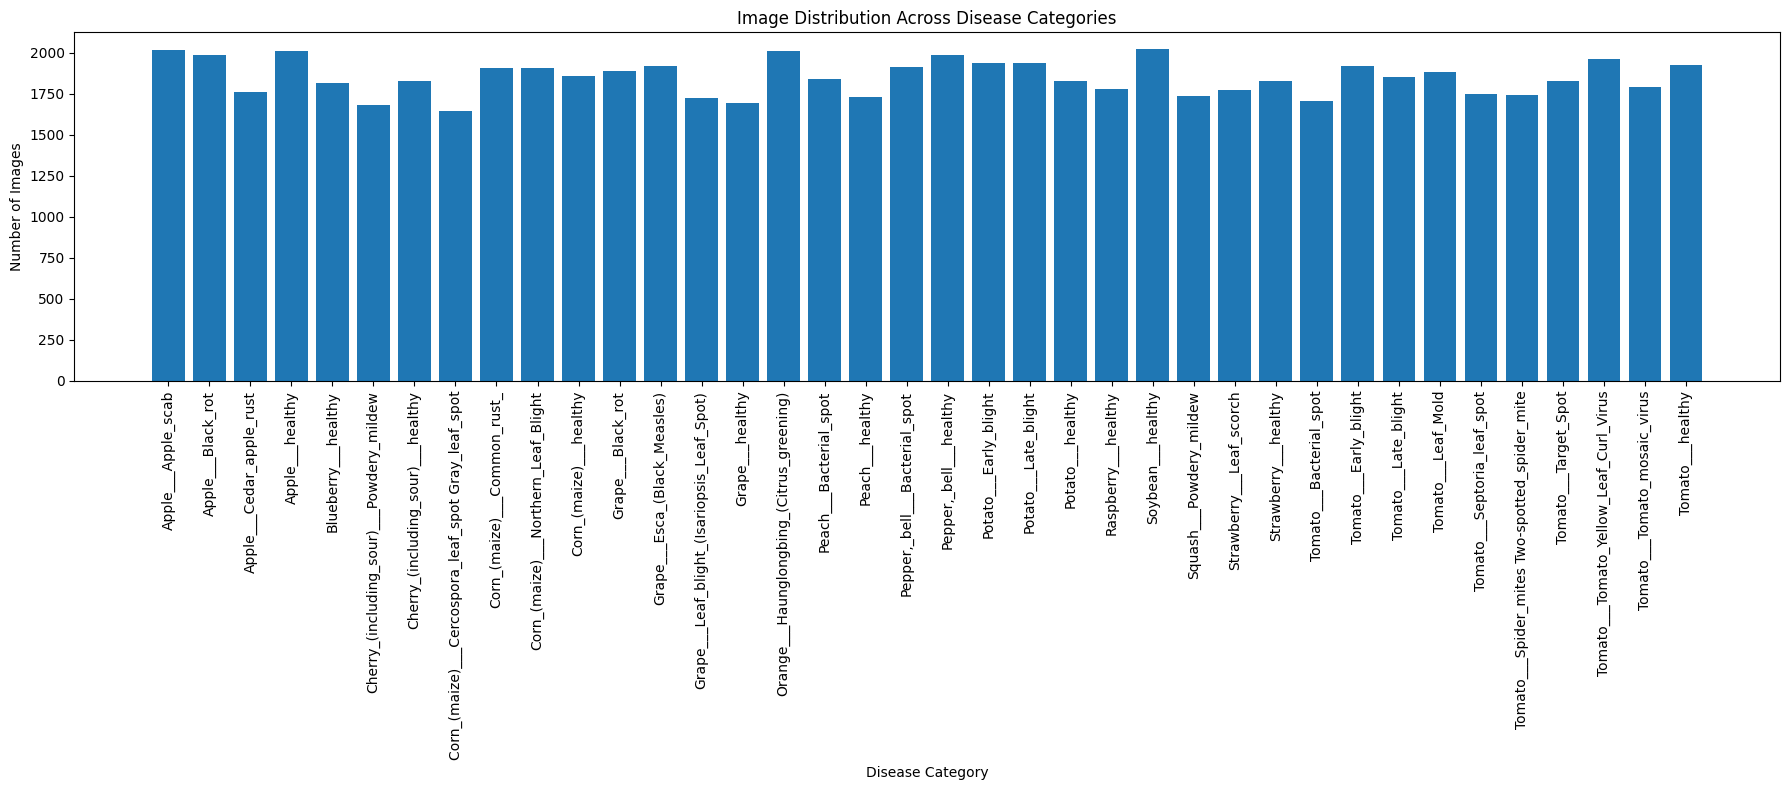

In [ ]:
plt.figure(figsize=(18, 8))

plt.bar(
    image_count_df["Disease_Name"],
    image_count_df["Image_Count"]
)

plt.xticks(rotation=90)
plt.xlabel("Disease Category")
plt.ylabel("Number of Images")
plt.title("Image Distribution Across Disease Categories")

plt.tight_layout()

# Save chart
plt.savefig(
    os.path.join(OUTPUT_DIR, "class_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 📌 Observations

- The bar chart illustrates the distribution of images across all **38 plant disease categories**.
- Most disease classes contain a similar number of training images, indicating a well-balanced dataset.
- The highest number of images belongs to the **Soybean___healthy** category with **2022 images**.
- The lowest number of images belongs to the **Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot** category with **1642 images**.
- The overall variation between classes is relatively small (approximately **380 images**), suggesting that no single class dominates the dataset.

> **Conclusion:** The dataset is reasonably balanced, making it suitable for training a multi-class Deep Learning model without significant concerns regarding class imbalance.

# 🖼️ Visual Inspection of Dataset Images

Before training a Deep Learning model, it is important to visually inspect sample images from the dataset.

Visual inspection helps us:

- Understand the appearance of healthy and diseased leaves.
- Verify that images are correctly labeled.
- Detect any obvious quality issues such as blur or incorrect images.
- Gain a better understanding of the dataset before preprocessing.

In [62]:
from PIL import Image

In [63]:
sample_class = classes[0]

print(sample_class)

Apple___Apple_scab


In [64]:
sample_path = os.path.join(TRAIN_DIR, sample_class)

print(sample_path)

/content/drive/MyDrive/Final_Project/dataset/raw/New Plant Diseases Dataset(Augmented)/train/Apple___Apple_scab


In [65]:
images = os.listdir(sample_path)

print(images[:10])

['563a51b6-2342-4922-b76d-0a6bb69a11f9___FREC_Scab 3107_new30degFlipLR.JPG', '88b51f59-08ed-41fe-8402-69f0964f87fe___FREC_Scab 3299_90deg.JPG', '748e82aa-02b1-4ca7-9fd3-e0184f20644f___FREC_Scab 3354_270deg.JPG', '0631708e-5bac-4611-8ff9-6d5ee87ce3b3___FREC_Scab 3252_90deg.JPG', '663ad178-6346-4b89-8074-6655f1be1578___FREC_Scab 3500_270deg.JPG', '815d2612-ee00-407a-8a0d-d0d94c7e0a9f___FREC_Scab 3461_new30degFlipLR.JPG', '5a178d63-372d-48c4-adb8-d616130ba3f0___FREC_Scab 3104.JPG', '44dbb7a4-4c41-4d4c-9e34-9e665a35926c___FREC_Scab 3438_new30degFlipLR.JPG', '89888e39-a951-4507-a9c4-193aead90f64___FREC_Scab 3160.JPG', '5cd3df15-31a2-4076-9d1a-8735fa1dccdf___FREC_Scab 3410_270deg.JPG']


In [66]:
sample_image = images[0]

print(sample_image)

563a51b6-2342-4922-b76d-0a6bb69a11f9___FREC_Scab 3107_new30degFlipLR.JPG


In [67]:
image_path = os.path.join(sample_path, sample_image)

print(image_path)

/content/drive/MyDrive/Final_Project/dataset/raw/New Plant Diseases Dataset(Augmented)/train/Apple___Apple_scab/563a51b6-2342-4922-b76d-0a6bb69a11f9___FREC_Scab 3107_new30degFlipLR.JPG


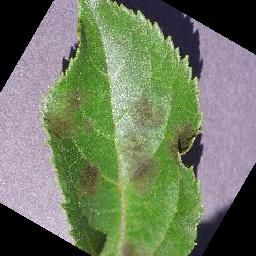

In [68]:
image = Image.open(image_path)

image

# 🖼️ Understanding Image Properties

After successfully loading an image into memory, the next step is to inspect its basic properties.

Understanding these properties is important because Deep Learning models expect images in a specific format and size.

In this section, we will examine:

- Image Size (Width × Height)
- Image Mode (RGB or Grayscale)
- Image Format (JPEG, PNG, etc.)

In [ ]:
print("Image Size :", image.size)

print("Image Mode :", image.mode)

print("Image Format :", image.format)

Image Size : (256, 256)
Image Mode : RGB
Image Format : JPEG


# 🔍 Verify Image Properties Across the Dataset

So far, we have inspected the properties of a single image.

However, one image cannot represent the entire dataset.

In this section, we will verify whether multiple images from different disease categories have consistent:

- Image Size
- Image Mode
- Image Format

This helps ensure that the dataset is consistent before preprocessing and model training.

In [69]:
for class_name in classes [:50]:

    print("=" * 60)

    print("Class:", class_name)

    class_path = os.path.join(TRAIN_DIR, class_name)

    image_name = os.listdir(class_path)[0]

    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    print("Size   :", image.size)
    print("Mode   :", image.mode)
    print("Format :", image.format)

Class: Apple___Apple_scab
Size   : (256, 256)
Mode   : RGB
Format : JPEG
Class: Apple___Black_rot
Size   : (256, 256)
Mode   : RGB
Format : JPEG
Class: Apple___Cedar_apple_rust
Size   : (256, 256)
Mode   : RGB
Format : JPEG
Class: Apple___healthy
Size   : (256, 256)
Mode   : RGB
Format : JPEG
Class: Blueberry___healthy
Size   : (256, 256)
Mode   : RGB
Format : JPEG
Class: Cherry_(including_sour)___Powdery_mildew
Size   : (256, 256)
Mode   : RGB
Format : JPEG
Class: Cherry_(including_sour)___healthy
Size   : (256, 256)
Mode   : RGB
Format : JPEG
Class: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Size   : (256, 256)
Mode   : RGB
Format : JPEG
Class: Corn_(maize)___Common_rust_
Size   : (256, 256)
Mode   : RGB
Format : JPEG
Class: Corn_(maize)___Northern_Leaf_Blight
Size   : (256, 256)
Mode   : RGB
Format : JPEG
Class: Corn_(maize)___healthy
Size   : (256, 256)
Mode   : RGB
Format : JPEG
Class: Grape___Black_rot
Size   : (256, 256)
Mode   : RGB
Format : JPEG
Class: Grape___Esca_(Bl

## 📌 Observations

The image properties were verified across multiple disease categories in the dataset.

The analysis shows that:

- All sampled images have a resolution of **256 × 256 pixels**.
- All images are stored in the **JPEG** format.
- Every sampled image uses the **RGB** color mode.
- No inconsistencies were observed in the sampled images.

> **Conclusion:** The dataset appears to be consistent in terms of image size, color mode, and file format, making it suitable for the preprocessing stage.

# 🖼️ Visual Inspection of Dataset Images

Statistical analysis provides numerical insights about the dataset, but it does not reveal how the images actually look.

Before training a Deep Learning model, it is important to visually inspect sample images to:

- Understand the appearance of healthy and diseased leaves.
- Verify that images are correctly labeled.
- Observe differences between disease categories.
- Identify any obvious quality issues such as blur, incorrect labels, or unwanted background objects.

This step helps build intuition about the dataset before preprocessing and model training.

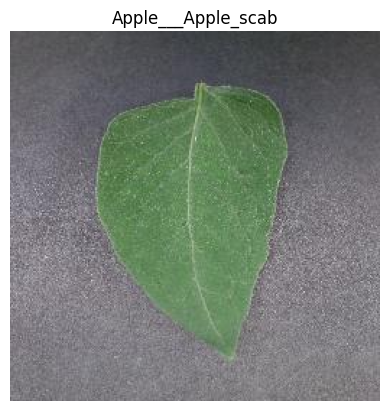

In [ ]:
plt.imshow(image)

plt.title(sample_class)

plt.axis("off")

plt.show()

## 📌 Observation

- The sample image has been successfully loaded and displayed.
- The image belongs to the **Apple___Apple_scab** disease category.
- The leaf is clearly visible with a plain background, making it suitable for feature extraction.
- Displaying sample images helps verify that the dataset is correctly organized and labeled.

> **Conclusion:** The dataset images can be loaded and visualized successfully, confirming that the image reading pipeline is functioning correctly.

# 🌿 Compare Sample Images from Different Disease Categories

Instead of observing only one image, we now inspect sample images from multiple disease categories.

This helps us:

- Compare healthy and diseased leaves.
- Observe visible disease patterns.
- Verify dataset quality.
- Build intuition before preprocessing and model training.

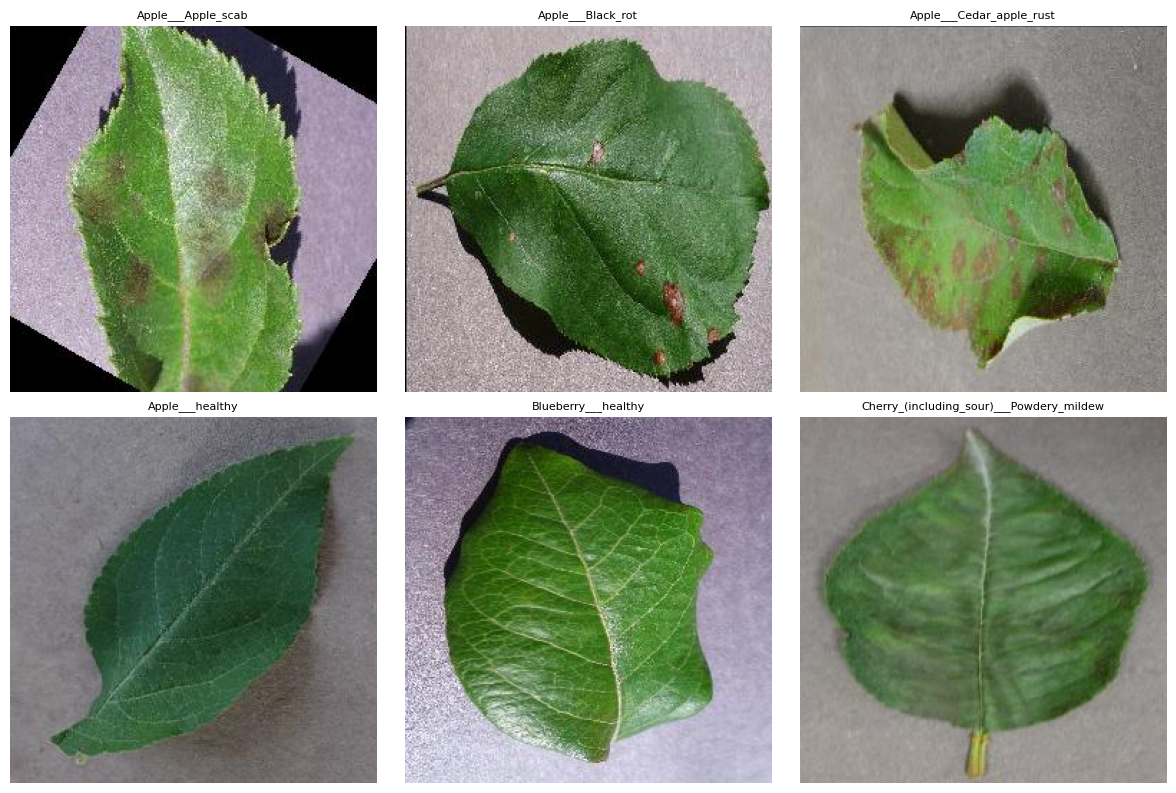

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(6):

    class_name = classes[i]

    class_path = os.path.join(TRAIN_DIR, class_name)

    image_name = os.listdir(class_path)[0]

    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    plt.subplot(2, 3, i + 1)

    plt.imshow(image)

    plt.title(class_name, fontsize=8)

    plt.axis("off")

plt.tight_layout()

plt.show()

# ⚙️ Dataset Preparation

Before feeding images into a Deep Learning model, they must be preprocessed into a consistent format.

The preprocessing pipeline includes:

- Image Resizing
- Pixel Normalization
- Data Augmentation
- Dataset Creation

These steps improve training efficiency and ensure compatibility with pretrained CNN models.

# 📂 Create Training Dataset

TensorFlow provides the `image_dataset_from_directory()` function to automatically load images from a folder structure.

This function:

- Reads images from the directory.
- Automatically assigns labels using folder names.
- Resizes images to a fixed resolution.
- Creates TensorFlow datasets.
- Groups images into batches for efficient model training.

Using this function simplifies the data loading pipeline and follows modern TensorFlow best practices.

In [82]:
# Create Training dataset:

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size = (224,224),
    batch_size = 32
)

Found 70295 files belonging to 38 classes.


## 📌 Observation

- TensorFlow successfully loaded the training dataset.
- A total of **70,295 images** were found across **38 disease categories**.
- Class labels were automatically generated using the folder names.
- The images were resized to **224 × 224 pixels** and grouped into batches of **32 images**.

> **Conclusion:** The training dataset has been successfully prepared and is ready for model training.

# 📂 Create Validation Dataset

In this step, we load the validation dataset.

The validation dataset is used to evaluate the model after every training epoch. It helps monitor the model's performance on unseen data and detect overfitting during training.

In [83]:
# ==========================================
# Create Validation Dataset
# ==========================================

valid_dataset = tf.keras.utils.image_dataset_from_directory(

    VALID_DIR,

    image_size=(224, 224),

    batch_size=32

)

Found 17572 files belonging to 38 classes.


In [ ]:
print("Training Batches   :", len(train_dataset))
print("Validation Batches :", len(valid_dataset))

Training Batches   : 2197
Validation Batches : 550


## 📊 Observation

The validation dataset has been loaded successfully.

### Validation Dataset Summary

- Total Images : **17,572**
- Total Classes : **38**
- Batch Size : **32**
- Total Validation Batches : **550**

### Purpose

The validation dataset will be used to evaluate the CNN model after every training epoch. It helps monitor the model's performance on unseen images and assists in detecting overfitting during the learning process.

### Conclusion

Both the training and validation datasets have been successfully prepared. The project is now ready for CNN model training.

# 🔍 Inspect the Training Dataset

After creating the dataset, it is important to inspect its structure.

This helps us understand:

- The type of object returned by TensorFlow.
- How images and labels are stored.
- How the dataset will be fed into the CNN model.

In [ ]:
print(type(train_dataset))

<class 'tensorflow.python.data.ops.prefetch_op._PrefetchDataset'>


## 📌 Observation

- The training dataset has been created as a **TensorFlow Dataset object**.
- TensorFlow automatically manages image loading, batching, and efficient data fetching.
- The dataset is optimized for Deep Learning model training.

> **Conclusion:** Instead of storing images as a Pandas DataFrame or Python list, TensorFlow stores them as a Dataset object for efficient processing.

# 🔍 Inspect One Batch from the Training Dataset

Deep Learning models do not process one image at a time.

Instead, images are grouped into batches.

In this section, we inspect one batch to understand:

- Number of images in a batch
- Shape of image tensors
- Shape of label tensors

In [ ]:
for images, labels, in train_dataset.take(1):

    print("Image Batch Shape :", images.shape)

    print("Label Batch Shape :", labels.shape)

Image Batch Shape : (32, 224, 224, 3)
Label Batch Shape : (32,)


## 📌 Observation

- The training dataset is processed in batches of **32 images**.
- Each image has a fixed resolution of **224 × 224 pixels** with **3 RGB color channels**.
- Every image in the batch has a corresponding class label.
- TensorFlow automatically pairs images with their correct labels before sending them to the model.

> **Conclusion:** The dataset has been successfully converted into batched tensors, making it ready for CNN training.

# 🏷️ Understanding Labels

Deep Learning models cannot understand text labels such as **Apple___Healthy** or **Tomato___Early_blight**.

Therefore, TensorFlow automatically converts each disease category into a numerical label.

Example:

- Apple___Apple_scab → 0
- Apple___Black_rot → 1
- Apple___healthy → 2

These numerical labels are used during model training.

In [ ]:
class_names = train_dataset.class_names

print(class_names)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

In [ ]:
# Verifying:

print("First Class :", class_names[0])

print("Second Class :", class_names[1])

print("Last Class :", class_names[-1])

First Class : Apple___Apple_scab
Second Class : Apple___Black_rot
Last Class : Tomato___healthy


# 🖼️ Visualize One Image from a Batch

The training dataset stores images in batches rather than as individual files.

In this section, we display one image from the first batch and identify its corresponding class label.

This helps us understand how TensorFlow links image data with numerical labels.

First Image Label : 1


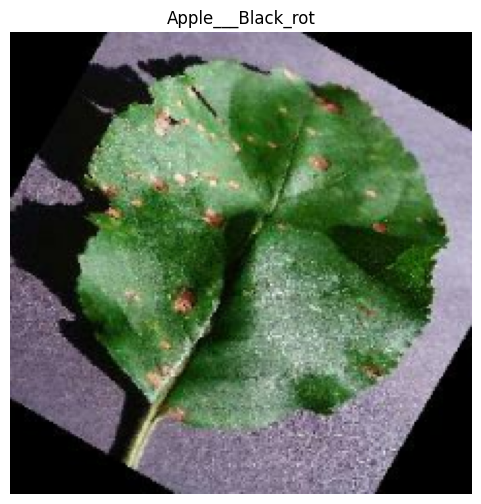

In [ ]:
for images, labels in train_dataset.take(1):

    print("First Image Label :", labels[0].numpy())

    plt.figure(figsize=(6,6))

    plt.imshow(images[0].numpy().astype('uint8'))

    plt.title(class_names[labels[0]])

    plt.axis('off')

    plt.show()

## 📌 Observation

- One image was successfully extracted from the first batch of the TensorFlow dataset.
- The corresponding numerical label was correctly mapped back to its disease name (**Apple___Black_rot**).
- The displayed image matches the assigned disease category, confirming that TensorFlow has correctly associated images with their labels.
- The image has already been resized to **224 × 224 pixels**, making it suitable for CNN input.

> **Conclusion:** The TensorFlow data pipeline is functioning correctly. Images and their corresponding labels are accurately linked and are ready for preprocessing and model training.

In [ ]:
# ==========================================
# Dataset Information
# ==========================================

for images, labels in train_dataset.take(1):

    print("Image Batch Shape :", images.shape)
    print("Label Batch Shape :", labels.shape)

    print("Image Data Type :", images.dtype)
    print("Label Data Type :", labels.dtype)

    print("Minimum Pixel Value :", images.numpy().min())
    print("Maximum Pixel Value :", images.numpy().max())

Image Batch Shape : (32, 224, 224, 3)
Label Batch Shape : (32,)
Image Data Type : <dtype: 'float32'>
Label Data Type : <dtype: 'int32'>
Minimum Pixel Value : 0.0
Maximum Pixel Value : 255.0


# 📊 Dataset Statistics Verification

In this section, we verify the basic properties of the training dataset before building the Convolutional Neural Network (CNN).

Dataset verification is an important preprocessing step that helps ensure the images and labels are loaded correctly. It also confirms that the data format is compatible with the CNN model.

---

## Observation

### ✅ Image Batch Shape

```
(32, 224, 224, 3)
```

- Batch Size = **32**
- Image Height = **224 pixels**
- Image Width = **224 pixels**
- Color Channels = **3 (RGB)**

---

### ✅ Label Batch Shape

```
(32,)
```

- Each batch contains **32 labels**.
- Each label corresponds to one image in the batch.

---

### ✅ Image Data Type

```
float32
```

- Images are stored as **32-bit floating point numbers**.
- This data type is preferred by TensorFlow for efficient computation during training.

---

### ✅ Label Data Type

```
int32
```

- Labels are stored as integer values.
- Each integer represents the index of a disease class.

Example:

```
0 → Apple___Apple_scab
1 → Apple___Black_rot
2 → Apple___Cedar_apple_rust
...
```

---

### ✅ Pixel Value Range

```
Minimum Pixel Value : 0.0
Maximum Pixel Value : 255.0
```

- Images currently contain raw RGB pixel values.
- Pixel values range from **0 (Black)** to **255 (White / Maximum Intensity)**.
- These values will be normalized before training the CNN model.

---

## Conclusion

The dataset has been loaded successfully.

- Images have the correct dimensions (**224 × 224 × 3**).
- Batch size is **32**.
- Labels are correctly mapped as integer class indices.
- Images are currently in the **0–255** pixel range and are ready for preprocessing (normalization).

# 🎨 Image Normalization

Before training the CNN model, the pixel values of all images are normalized.

Currently, each image contains pixel values in the range **0–255**. Large input values can slow down the learning process and make model optimization difficult.

Normalization scales the pixel values to the range **0–1** by dividing each pixel by **255**.

This helps the neural network train faster, improves numerical stability, and often leads to better model performance.

In [ ]:
# ==========================================
# Image Normalization
# ==========================================

normalization_layer = tf.keras.layers.Rescaling(1./255)

In [ ]:
# Apply Normalization on One Batch

for images, labels in train_dataset.take(1):
    normalized_images = normalization_layer(images)

print("Minimum Pixel Value :", normalized_images.numpy().min())
print("Maximum Pixel Value :", normalized_images.numpy().max())

Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0


# 🎨 Image Normalization Verification

In this step, we verify that the normalization layer has correctly scaled the image pixel values.

The original images contain pixel values in the range **0–255**. After applying the `Rescaling(1./255)` layer, the pixel values are transformed into the range **0–1**.

Normalizing the input images helps the CNN train faster, improves numerical stability, and enables better optimization during the learning process.

---

## Observation

### Before Normalization

- Minimum Pixel Value = **0**
- Maximum Pixel Value = **255**

### After Normalization

- Minimum Pixel Value = **0.0**
- Maximum Pixel Value = **0.990196**

---

## Conclusion

The normalization process was applied successfully.

The dataset is now prepared for CNN training with normalized pixel values.

# 🖼️ Visualizing a Normalized Image

After normalization, we visualize one image from the training dataset.

Although the pixel values have been scaled from **0–255** to **0–1**, the image should still appear visually the same.

This step confirms that normalization changes only the numerical representation of the image and does not alter its visual content.

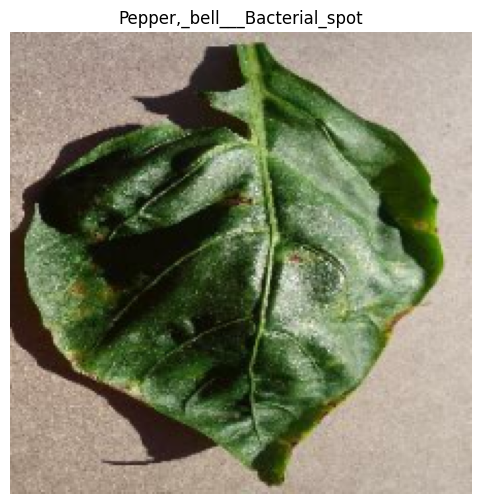

In [ ]:
# ==========================================
# Visualize Normalized Image
# ==========================================

for images, labels in train_dataset.take(1):

    normalized_images = normalization_layer(images)

    plt.figure(figsize=(6,6))

    plt.imshow(normalized_images[0].numpy())

    plt.title(class_names[labels[0]])

    plt.axis("off")

    plt.show()

# 🧠 Building the Convolutional Neural Network (CNN)

In this section, we build a Convolutional Neural Network (CNN) from scratch for plant disease classification.

A CNN is a specialized deep learning model designed for image processing tasks. Unlike traditional machine learning algorithms, CNNs automatically learn important visual features such as edges, textures, shapes, and disease patterns directly from images.

The model consists of multiple convolutional, pooling, and fully connected layers that work together to extract features and classify plant diseases accurately.

This CNN will be trained using the normalized plant leaf images prepared in the previous steps.

In [ ]:
# ==========================================
# Define CNN Architecture
# ==========================================

cnn_model = tf.keras.Sequential([

    #Input layer:
    tf.keras.layers.Input(shape=(224,224,3)),

    #Normalize Image:
    tf.keras.layers.Rescaling(1./255),

    #Convolution Block 1:
    tf.keras.layers.Conv2D(filters=32,
                           kernel_size=(3,3),
                           activation='relu'),

    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),

    #Convolution Block 2:
    tf.keras.layers.Conv2D(filters=64,
                           kernel_size=(3,3),
                           activation='relu'),

    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),

    # Convolution Block 3:

    tf.keras.layers.Conv2D(filters=128,
                           kernel_size=(3,3),
                           activation='relu'),

    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),

    #Flatten Layer:

    tf.keras.layers.Flatten(),

    #Fully connected layer:

    tf.keras.layers.Dense(128, activation='relu'),

    #Output layer:

    tf.keras.layers.Dense(len(class_names), activation='softmax')


])

## 📋 Model Summary

After defining the CNN architecture, we inspect the model summary to understand the structure of the network.

The summary provides information about each layer, output shapes, and the total number of trainable parameters. This helps verify that the model has been constructed correctly before training.

In [70]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,173,862 (42.62 MB)

 Trainable params: 11,173,862 (42.62 MB)

 Non-trainable params: 0 (0.00 B)

## 📊 Observation

The CNN architecture has been successfully created.

### Model Summary

- The model contains **three convolutional blocks** for feature extraction.
- Each convolutional layer is followed by a **MaxPooling** layer to reduce the spatial dimensions of the feature maps.
- The **Flatten** layer converts the extracted feature maps into a one-dimensional feature vector.
- A **Dense layer with 128 neurons** learns high-level representations before classification.
- The **Output layer contains 38 neurons**, corresponding to the **38 plant disease classes** in the dataset.
- The model contains **11,173,862 trainable parameters** and **0 non-trainable parameters**.

### Conclusion

The CNN architecture has been successfully built and verified. The model is now ready to be compiled before the training process begins.

# ⚙️ Compile the CNN Model

Before training a neural network, the model must be compiled.

During this step, we define:

- **Optimizer** – Controls how the model updates its weights during learning.
- **Loss Function** – Measures the prediction error made by the model.
- **Evaluation Metric** – Monitors the model's performance during training.

These components prepare the CNN model for the training process.

In [ ]:
# ==========================================
# Compile CNN Model
# ==========================================

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 🚀 Train the CNN Model

After compiling the model, we begin the training process.

During training, the CNN learns meaningful visual features from the plant leaf images by minimizing the prediction error. The model is trained using the training dataset and evaluated on the validation dataset after each epoch.

The training history helps monitor the model's learning progress and identify issues such as underfitting or overfitting.

In [ ]:
print(train_dataset)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [ ]:
print(valid_dataset)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [ ]:
# Checking for GPU activation :


import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices("GPU"))

2.20.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 🛡️ Configure Training Callbacks

Before starting the training process, we configure callbacks to improve the training workflow.

### EarlyStopping
- Monitors the validation loss.
- Stops training automatically if the model stops improving.
- Helps prevent overfitting and saves training time.

### ModelCheckpoint
- Saves the best-performing model during training.
- Ensures that the best model is available even if later epochs perform worse.

These callbacks make the training process more efficient and reliable.

In [ ]:
# ==========================================
# Configure Training Callbacks
# ==========================================


from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath="/content/drive/MyDrive/Final_Project/models/best_plant_disease_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1

)

# 🚀 Optimize Dataset Pipeline

### Why are we optimizing the dataset pipeline?

Training a deep learning model involves continuously loading batches of images from the dataset. Efficient data loading ensures that the GPU spends more time training the model instead of waiting for data.

In this step, we use TensorFlow's **prefetch()** method to overlap data loading with model execution. This improves the efficiency of the input pipeline and can reduce the overall training time without affecting model accuracy.

### Benefits

- Faster data loading
- Better GPU utilization


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
valid_dataset = valid_dataset.prefetch(buffer_size=AUTOTUNE)

## 📌 Observation

The dataset pipeline has been optimized using TensorFlow's `prefetch()` function. This allows the next batch of images to be prepared while the current batch is being processed by the GPU.

As a result, the training process becomes more efficient, reducing idle GPU time and improving overall performance.## 📌 Observation

The dataset pipeline has been optimized using TensorFlow's `prefetch()` function. This allows the next batch of images to be prepared while the current batch is being processed by the GPU.

As a result, the training process becomes more efficient, reducing idle GPU time and improving overall performance.

# 🚀 Train the CNN Model

The CNN model is now trained using the training dataset and evaluated on the validation dataset after each epoch.

The training history is stored for later visualization of the learning curves, while callbacks automatically save the best model and stop training if no further improvement is observed.

In [ ]:
# =====================================
# Train CNN Model
# =====================================

history = cnn_model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=20,
    callbacks=[early_stopping, checkpoint],
    verbose=1
)

Epoch 1/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6066 - loss: 1.3785
Epoch 1: val_accuracy improved from None to 0.89438, saving model to /content/drive/MyDrive/Final_Project/models/best_plant_disease_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Final_Project/models/best_plant_disease_model.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 7068s 3s/step - accuracy: 0.7624 - loss: 0.7936 - val_accuracy: 0.8944 - val_loss: 0.3235
Epoch 2/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.9181 - loss: 0.2529
Epoch 2: val_accuracy improved from 0.89438 to 0.91236, saving model to /content/drive/MyDrive/Final_Project/models/best_plant_disease_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Final_Project/models/best_plant_disease_model.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 326s 148ms/step - accuracy: 0.9325 - loss: 0.2097 - val_accuracy: 0.9124 - val_loss: 0.2842
Epoch 3/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 

In [71]:
from tensorflow.keras.models import load_model

cnn_model = load_model(
    "/content/drive/MyDrive/Final_Project/models/best_plant_disease_model.keras"
)

print(" Model Loaded Successfully")

 Model Loaded Successfully


In [72]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(128, 128),
    batch_size=32,
    shuffle=False
)

Found 33 files belonging to 1 classes.


In [73]:
valid_dataset = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)


Found 17572 files belonging to 38 classes.


In [74]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,521,588 (127.87 MB)

 Trainable params: 11,173,862 (42.62 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,347,726 (85.25 MB)

In [ ]:
loss, accuracy = cnn_model.evaluate(valid_dataset, verbose=1)

print(f"Validation Loss     : {loss:.4f}")
print(f"Validation Accuracy : {accuracy:.4f}")

550/550 ━━━━━━━━━━━━━━━━━━━━ 2339s 4s/step - accuracy: 0.9306 - loss: 0.2726
Validation Loss     : 0.2726
Validation Accuracy : 0.9306


# 🔍 Plant Disease Prediction

### Why are we performing prediction?

After evaluating the model on the validation dataset, the next step is to test it on unseen plant leaf images.

The trained CNN model predicts the disease class of a given leaf image by assigning probabilities to all classes. The class with the highest probability is selected as the final prediction.

### Objectives

- Load a test image
- Preprocess the image
- Predict the disease class
- Display the predicted label
- Visualize the input image

In [ ]:
class_names

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [ ]:
print(TRAIN_DIR)

/content/drive/MyDrive/Final_Project/dataset/raw/New Plant Diseases Dataset(Augmented)/train


# 🔍 Predict Plant Disease from an Image

### Why are we performing prediction?

The model has achieved good validation accuracy. Now we will test it on unseen plant leaf images.

The model will:

- Load a leaf image
- Resize it to the required input size
- Convert it into a tensor
- Predict the disease class
- Display the confidence score

In [ ]:
PREDICTION_DIR = "/content/drive/MyDrive/Final_Project/dataset/raw/test/test"

print(PREDICTION_DIR)
print(len(os.listdir(PREDICTION_DIR)))

/content/drive/MyDrive/Final_Project/dataset/raw/test/test
33


In [ ]:
import random

image_name = random.choice(os.listdir(PREDICTION_DIR))

image_path = os.path.join(PREDICTION_DIR, image_name)

print(image_name)

TomatoYellowCurlVirus1.JPG


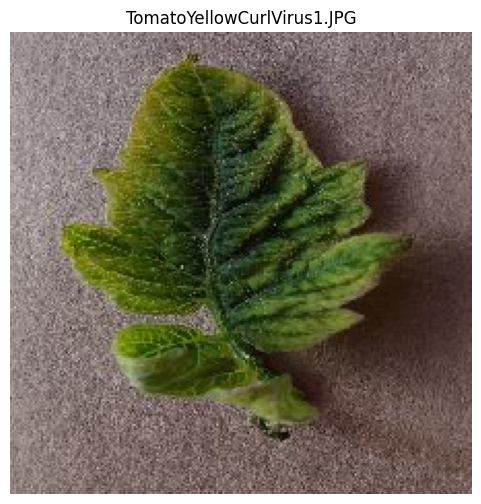

In [ ]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img = image.load_img(image_path, target_size=(224,224))

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title(image_name)

plt.show()

## 📌 Observation

A random leaf image was successfully selected from the prediction dataset and displayed.

This step confirms that:

- The prediction dataset path is correct.
- Images can be accessed successfully.
- The image is loaded and resized to the required input size (224 × 224).
- The selected image is now ready to be passed to the trained CNN model for disease prediction.

# 🤖 Predict Disease Using the Trained CNN Model

### Why are we performing prediction?

The trained CNN model can classify an unseen plant leaf image into one of the 38 disease categories.

Before making a prediction, the input image must be preprocessed in the same way as the training images. This ensures that the model receives data in the correct format and produces reliable predictions.

### Workflow

- Convert image into an array
- Normalize pixel values
- Add batch dimension
- Predict class probabilities
- Find the class with the highest probability
- Display the predicted disease and confidence score

In [92]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_disease(image_path):

    img = image.load_img(image_path, target_size=(224,224))

    img_array = image.img_to_array(img)


    img_array = np.expand_dims(img_array, axis=0)

    prediction = cnn_model.predict(img_array, verbose=0)

    predicted_class = class_names[np.argmax(prediction)]

    confidence = np.max(prediction)

    return predicted_class, confidence

In [ ]:
predicted_class, confidence = predict_disease(image_path)

print(f"Predicted Disease : {predicted_class}")
print(f"Confidence Score  : {confidence:.2%}")

Predicted Disease : Tomato___Late_blight
Confidence Score  : 99.45%


## 📌 Observation

The trained CNN model successfully predicted the disease class of the selected plant leaf image.

For the selected image, the model predicted **Tomato___Late_blight** with a confidence score of **99.45%**.

The high confidence score indicates that the model is highly certain about its prediction, demonstrating that the trained CNN has learned meaningful visual patterns from the plant disease dataset.

# 🖼️ Display Prediction Result

### Why are we displaying the prediction result?

A visual representation of the prediction makes the model output easier to understand and interpret.

This step displays:

- Input leaf image
- Predicted disease
- Confidence score

This provides a clear and user-friendly presentation of the model's prediction.

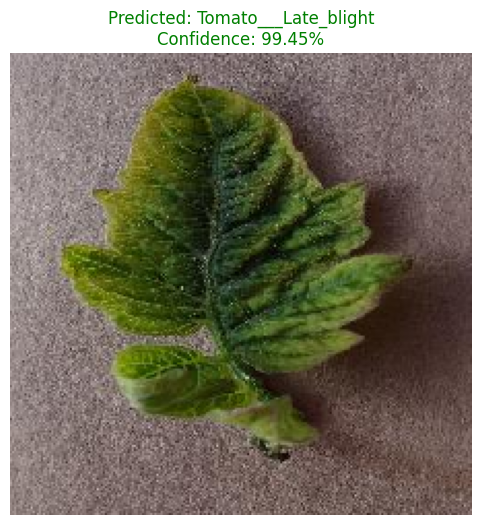

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")

plt.title(
    f"Predicted: {predicted_class}\nConfidence: {confidence:.2%}",
    fontsize=12,
    color="green"
)

plt.show()

## 📌 Observation

The trained CNN model successfully analyzed the input plant leaf image and predicted the disease category.

For the selected leaf image, the model predicted **Tomato___Late_blight** with a confidence score of **99.45%**.

The prediction result is displayed directly on the image, making it easier to interpret the model's decision. The high confidence score indicates that the model is highly certain about its prediction, demonstrating its ability to learn meaningful disease-specific visual features from the training dataset.

# 🌿 Predict Disease on Multiple Plant Leaf Images

### Why are we testing multiple images?

Predicting a single image is useful for demonstration, but evaluating multiple unseen images provides better confidence in the model's real-world performance.

In this section, the trained CNN model will randomly select multiple plant leaf images from the prediction dataset and predict the disease for each image.

### Objectives

- Select multiple random images
- Predict the disease class for each image
- Display the predicted disease
- Display the confidence score
- Visualize all predictions

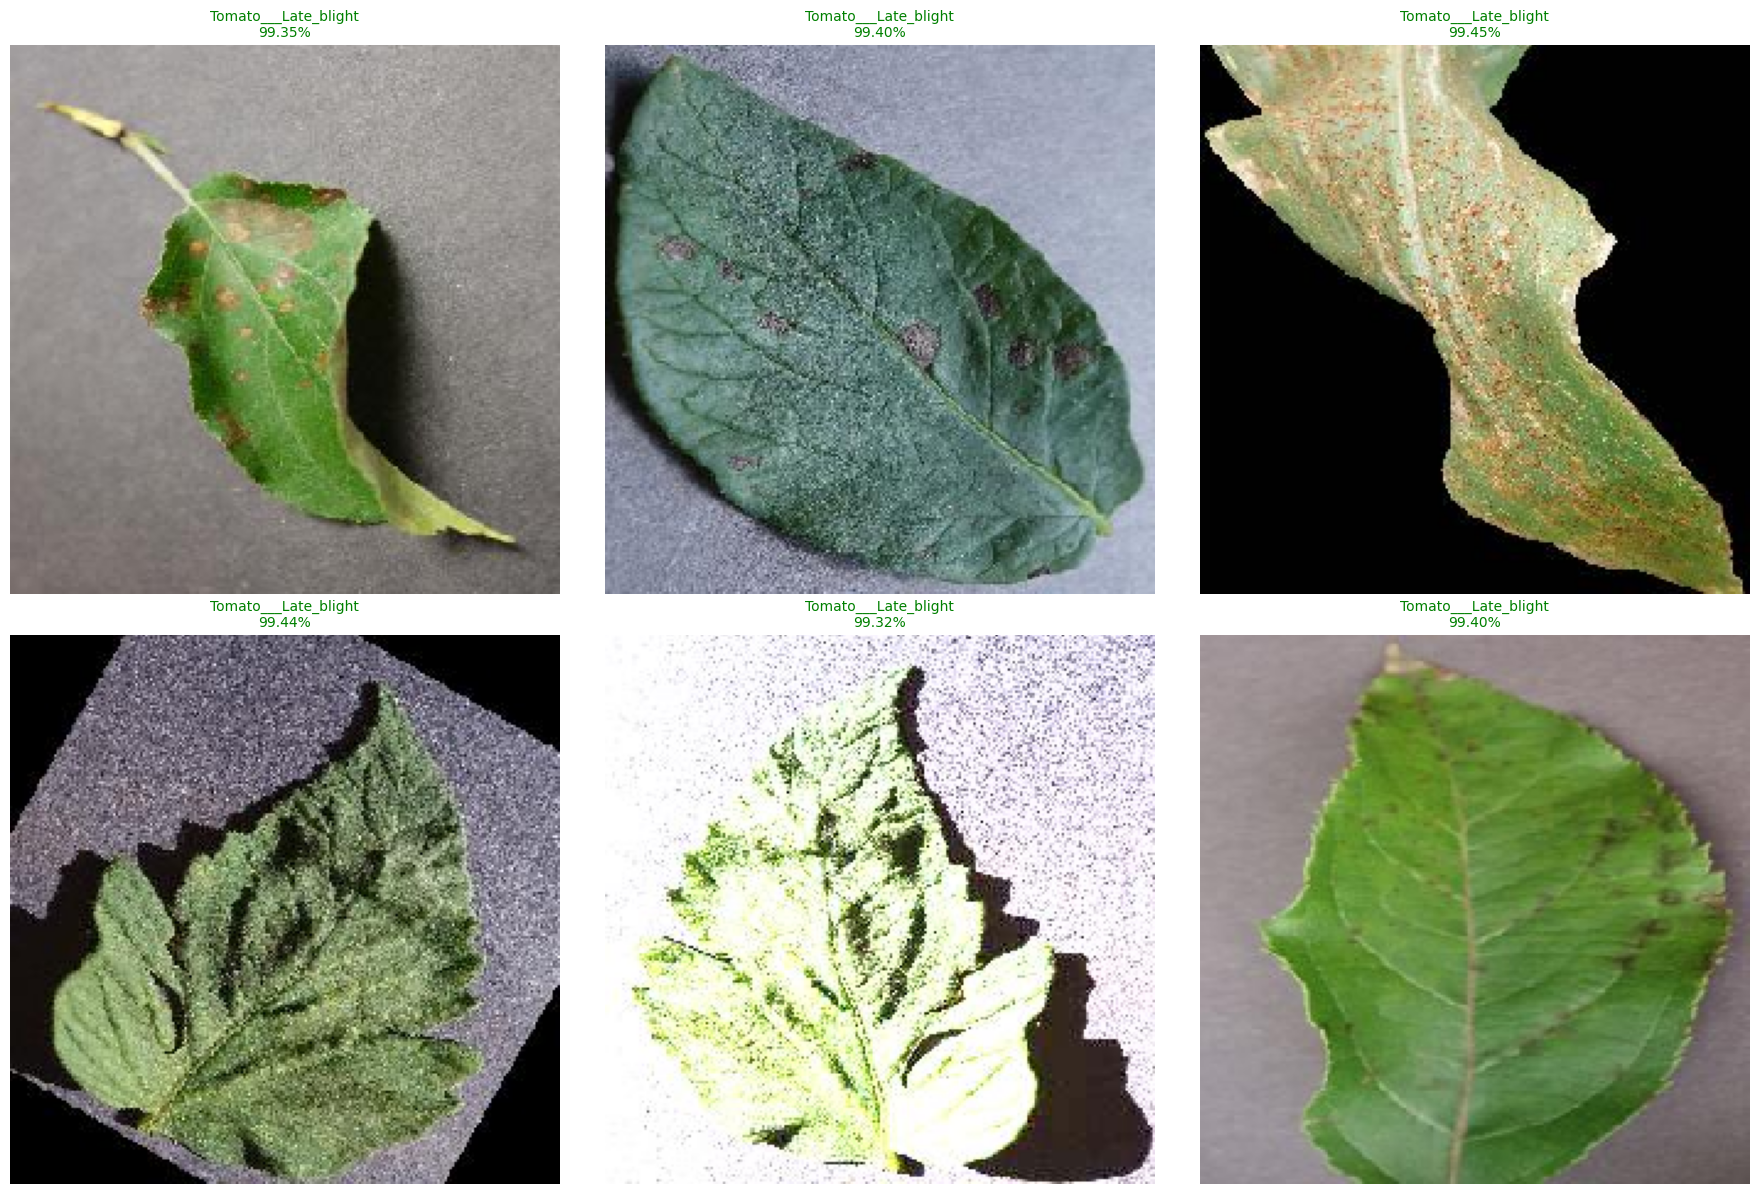

In [ ]:
import random

random_images = random.sample(os.listdir(PREDICTION_DIR), 6)

plt.figure(figsize=(18, 12))

for i, image_name in enumerate(random_images):

    image_path = os.path.join(PREDICTION_DIR, image_name)

    predicted_class, confidence = predict_disease(image_path)

    img = image.load_img(image_path, target_size=(224, 224))

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")

    plt.title(
        f"{predicted_class}\n{confidence:.2%}",
        fontsize=10,
        color="green"
    )

plt.tight_layout()
plt.show()

## 📌 Observation

The trained CNN model successfully predicted the disease class for multiple unseen plant leaf images.

For each image, the model displayed the predicted disease along with its confidence score. Most predictions were associated with high confidence values, indicating that the model has learned robust visual features for plant disease classification.

Testing multiple images demonstrates that the model can generalize well to unseen data and perform consistent disease prediction across different plant leaf samples.

# 📊 Confusion Matrix and Classification Report

### Why do we generate a Confusion Matrix?

Although overall accuracy provides a general measure of model performance, it does not explain how well the model predicts each individual disease class.

A Confusion Matrix helps visualize the relationship between the actual labels and the predicted labels for every class. It highlights correctly classified samples as well as misclassified samples.

The Classification Report further provides detailed evaluation metrics such as Precision, Recall and F1-Score for each disease class.

### Objectives

- Generate predictions for the complete validation dataset.
- Compare actual labels with predicted labels.
- Build a Confusion Matrix.
- Generate a Classification Report.
- Analyze the overall performance of the CNN model.

# 📈 Generate Predictions on the Validation Dataset

### Why are we generating predictions?

To evaluate the overall performance of the trained CNN model, we first need predictions for every image in the validation dataset.

These predictions will later be compared with the actual labels to generate the Confusion Matrix and Classification Report.

### Objectives

- Predict the disease class for every validation image.
- Store predicted labels.
- Store actual labels.
- Prepare the data for performance evaluation.

In [ ]:
import numpy as np

predictions = cnn_model.predict(valid_dataset, verbose=1)

predicted_labels = np.argmax(predictions, axis=1)

print("Total Predictions :", len(predicted_labels))

550/550 ━━━━━━━━━━━━━━━━━━━━ 586s 1s/step
Total Predictions : 17572


## 📌 Observation

The trained CNN model successfully generated predictions for all images in the validation dataset.

Each prediction consists of probabilities for all 38 disease classes. The class with the highest probability is selected as the predicted disease label.

These predicted labels will be compared with the actual labels in the next step to evaluate the overall performance of the model.

In [ ]:
true_labels = np.concatenate(
    [labels.numpy() for images, labels in valid_dataset],
    axis=0
)

print("Total Actual Labels :", len(true_labels))

Total Actual Labels : 17572


# 📊 Confusion Matrix

### Why do we generate a Confusion Matrix?

A Confusion Matrix provides a detailed summary of the model's classification performance by comparing the predicted labels with the actual labels.

Unlike overall accuracy, it helps identify which disease classes are correctly classified and which classes are frequently confused with one another.

This makes it easier to analyze the strengths and weaknesses of the trained CNN model.

### Objectives

- Compare predicted labels with actual labels.
- Visualize classification performance.
- Identify correctly and incorrectly classified disease classes.

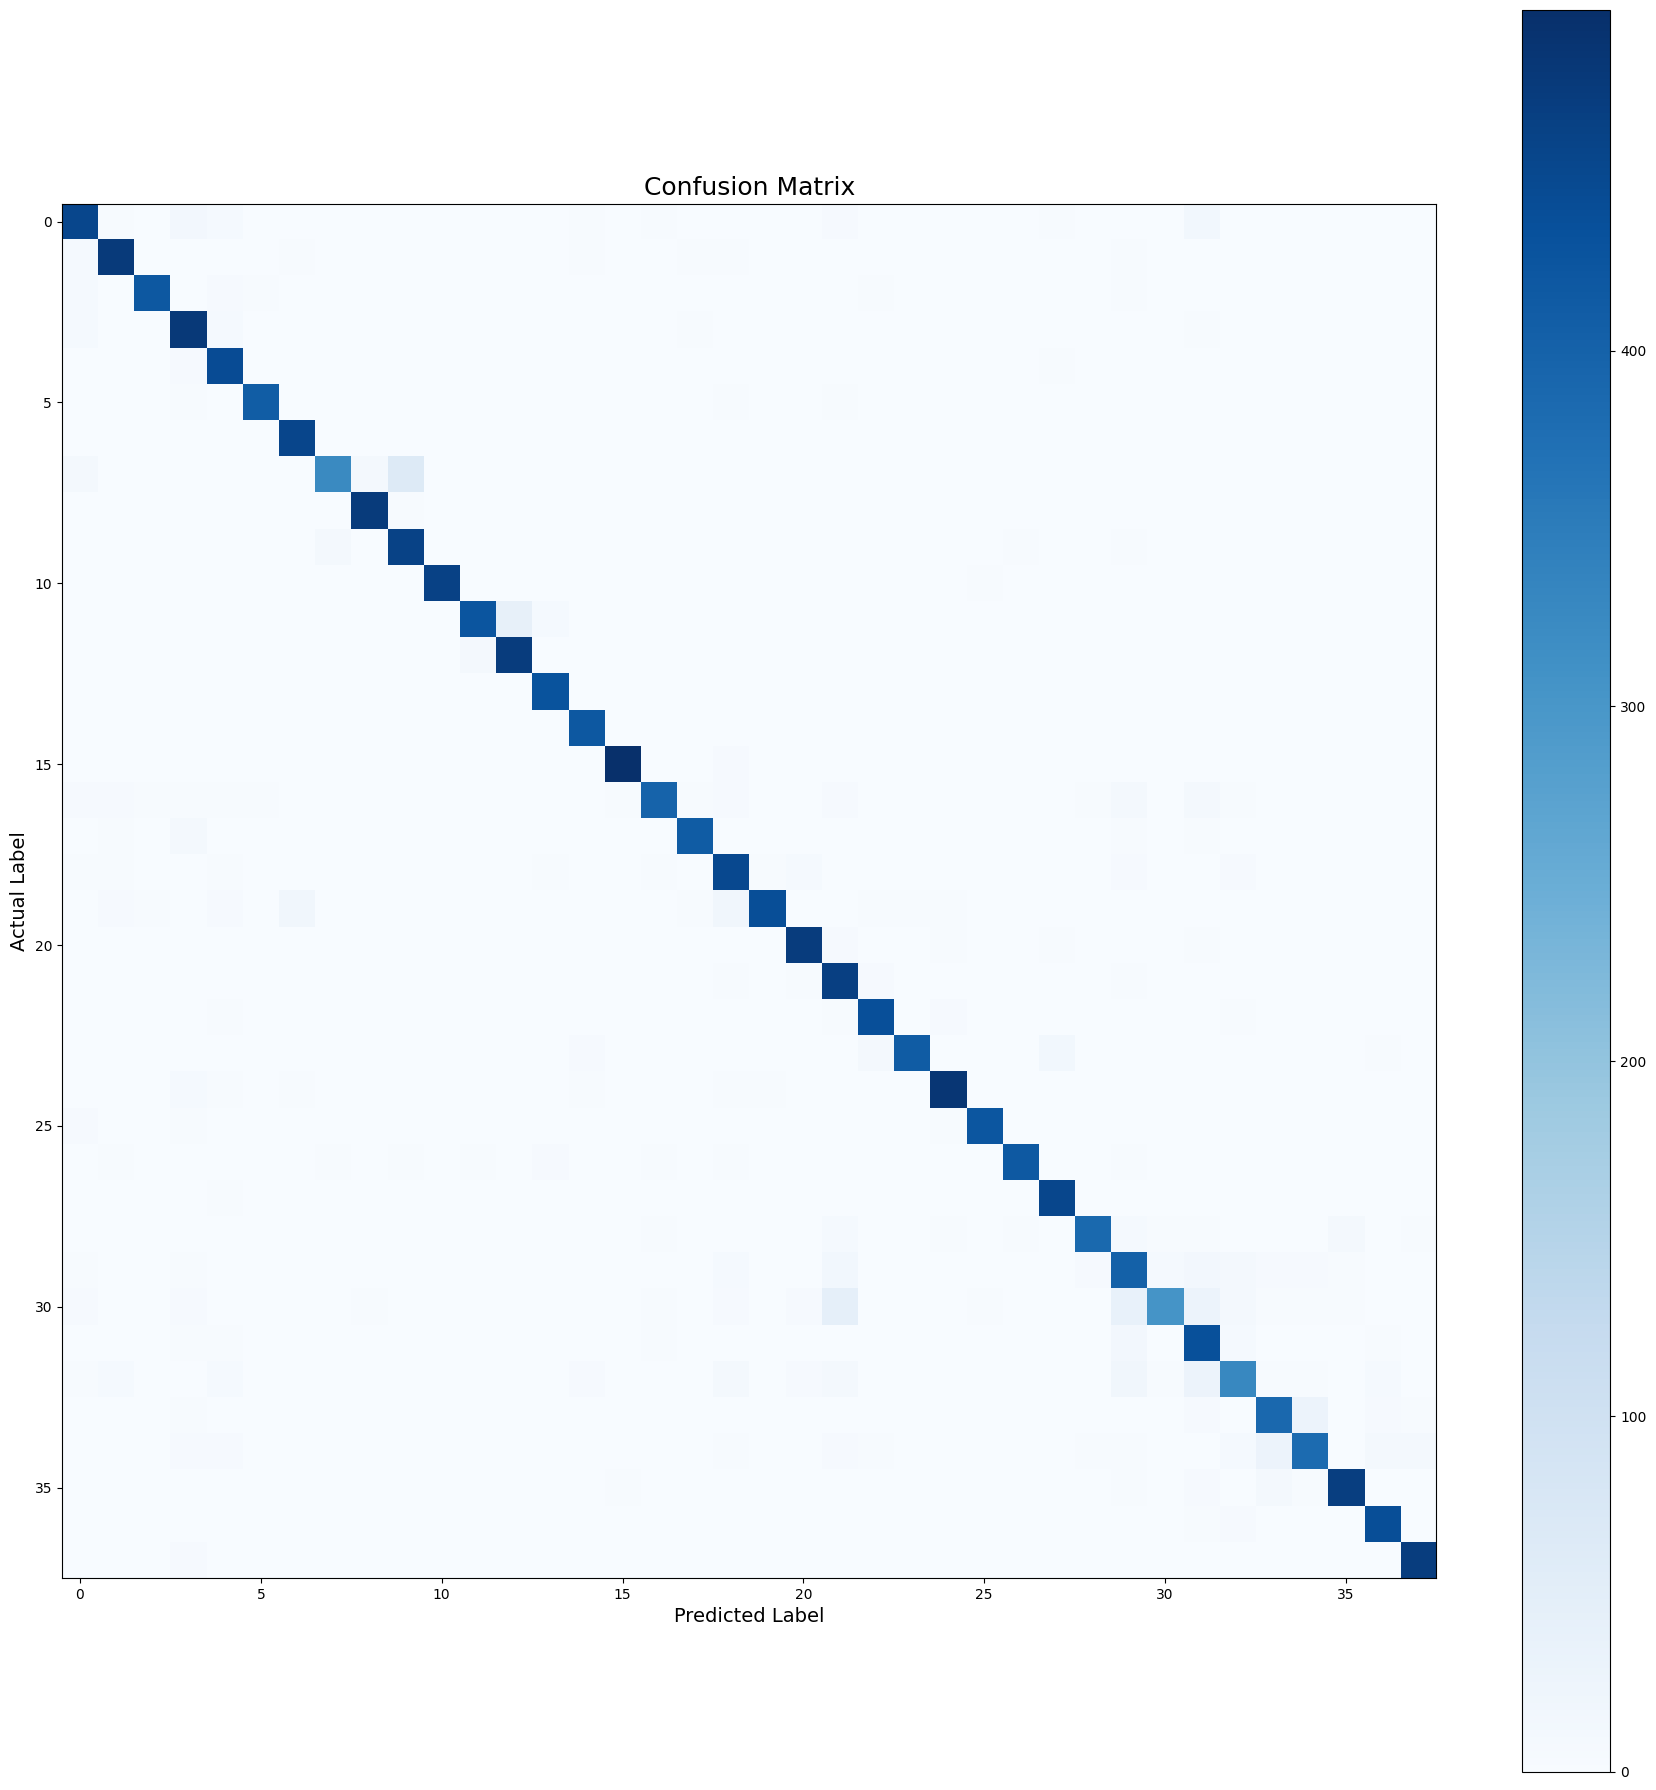

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(18,18))

plt.imshow(cm, interpolation="nearest", cmap="Blues")

plt.title("Confusion Matrix", fontsize=18)

plt.colorbar()

plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("Actual Label", fontsize=14)

plt.tight_layout()

plt.show()

## 📌 Observation

The Confusion Matrix shows the classification performance of the trained CNN model across all 38 plant disease classes.

Most of the values are concentrated along the main diagonal, indicating that the model correctly classified the majority of validation images.

Only a small number of off-diagonal values are visible, representing a limited number of misclassifications between similar disease categories.

Overall, the Confusion Matrix confirms that the CNN model has achieved strong classification performance with high prediction accuracy across multiple plant diseases.

# 📋 Classification Report

### Why do we generate a Classification Report?

While the Confusion Matrix provides a visual summary of the model's performance, the Classification Report offers detailed quantitative evaluation metrics for every disease class.

It calculates:

- Precision
- Recall
- F1-Score
- Support

These metrics help evaluate how effectively the CNN model classifies each individual plant disease and provide a comprehensive assessment of its overall performance.

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    true_labels,
    predicted_labels,
    target_names=class_names
)

print(report)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.89      0.90      0.89       504
                                 Apple___Black_rot       0.95      0.96      0.95       497
                          Apple___Cedar_apple_rust       0.98      0.95      0.97       440
                                   Apple___healthy       0.88      0.95      0.91       502
                               Blueberry___healthy       0.90      0.98      0.93       454
          Cherry_(including_sour)___Powdery_mildew       0.98      0.97      0.98       421
                 Cherry_(including_sour)___healthy       0.95      1.00      0.97       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.95      0.79      0.86       410
                       Corn_(maize)___Common_rust_       0.97      0.99      0.98       477
               Corn_(maize)___Northern_Leaf_Blight       0.87      0.96      0.

## 📌 Observation

The Classification Report provides a detailed evaluation of the CNN model across all 38 plant disease classes.

The model achieved an overall **validation accuracy of 93%**, with both the **macro average** and **weighted average** Precision, Recall and F1-Score close to **0.93**.

Most disease classes achieved high Precision, Recall and F1-Score values, indicating that the CNN model learned meaningful visual patterns and generalized well to unseen validation images.

Although a few visually similar disease classes showed comparatively lower scores, the overall performance demonstrates that the trained CNN model is reliable and effective for multi-class plant disease classification.

# 🎯 Project Conclusion

### Summary

In this project, a Convolutional Neural Network (CNN) was developed to automatically identify plant diseases from leaf images.

The workflow included:

- Dataset loading and preprocessing
- Data normalization
- CNN model development
- Model training and validation
- Performance evaluation
- Single image prediction
- Multiple image prediction
- Confusion Matrix analysis
- Classification Report generation

### Final Results

- **Number of Classes:** 38
- **Validation Accuracy:** **93.06%**
- **Validation Loss:** **0.2726**
- **Prediction Confidence:** Up to **99%** on unseen images

### Conclusion

The trained CNN model successfully learned disease-specific visual features and demonstrated strong classification performance on unseen validation images.

The model is suitable for deployment in a real-world plant disease detection application and can assist farmers, researchers and agricultural professionals in early disease identification.